In [7]:
import numpy as np
import pandas as pd 
from scipy.stats import chi2_contingency

In [8]:
np.random.seed(42)
num_records = 10000
customer_segments = np.random.choice(
    ["Premium Gold", "Regular Plus", "Guest User"],
    size=num_records,
    p=[0.3, 0.5, 0.2],
)
df = pd.DataFrame({"Customer_Segment": customer_segments})
def assign_return_status(segment):
    if segment == "Premium Gold":
        return np.random.choice(["Yes", "No"], p=[0.15, 0.85])
    elif segment == "Regular Plus":
        return np.random.choice(["Yes", "No"], p=[0.25, 0.75])
    else:
        return np.random.choice(["Yes", "No"], p=[0.40, 0.60])
df["Order_Returned"] = df["Customer_Segment"].apply(assign_return_status)

print(len(df))
df.head(10)

10000


,Customer_Segment,Order_Returned
0,Regular Plus,No
1,Guest User,Yes
2,Regular Plus,Yes
3,Regular Plus,No
4,Premium Gold,No
5,Premium Gold,No
6,Premium Gold,Yes
7,Guest User,No
8,Regular Plus,No
9,Regular Plus,No


In [9]:

observed_with_totals = pd.crosstab(
    df["Customer_Segment"],
    df["Order_Returned"],
    margins=True,
    margins_name="Total",
)
print("--- Observed Contingency Table (with Totals) ---")
print(observed_with_totals)
observed_matrix = pd.crosstab(df["Customer_Segment"], df["Order_Returned"])

--- Observed Contingency Table (with Totals) ---
Order_Returned      No   Yes  Total
Customer_Segment                   
Guest User        1186   776   1962
Premium Gold      2587   466   3053
Regular Plus      3757  1228   4985
Total             7530  2470  10000


In [4]:
chi2_stat, p_val, dof, expected_array = chi2_contingency(observed_matrix)
expected_df = pd.DataFrame(
    expected_array, columns=observed_matrix.columns, index=observed_matrix.index
)
print(f"Chi-Square Statistic (χ²): {chi2_stat:.4f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Calculated P-Value: {p_val}")
print("\n--- Expected Values DataFrame ---")
print(expected_df.round(2))

Chi-Square Statistic (χ²): 378.8490
Degrees of Freedom (dof): 2
Calculated P-Value: 5.419757210305124e-83

--- Expected Values DataFrame ---
Order_Returned         No      Yes
Customer_Segment                  
Guest User        1477.39   484.61
Premium Gold      2298.91   754.09
Regular Plus      3753.70  1231.30


In [10]:
alpha = 0.05 

print(f"Alpha Level: {alpha}")
print(f"P-Value: {p_val}")

if p_val < alpha:
    print("\n[RESULT]: REJECT THE NULL HYPOTHESIS (H0)")
    print(
        "[INSIGHT]: Customer Segment and Order Returns are STRONGLY DEPENDENT."
    )
    print(
        "[BUSINESS ACTION]: Guest users have a huge 40% return rate. Strategy team must optimize the guest checkout flow or offer loyalty incentives to convert them to regular users."
    )
else:
    print("\n[RESULT]: FAIL TO REJECT THE NULL HYPOTHESIS (H0)")
    print(
        "[INSIGHT]: Customer Segment and Order Returns are completely independent."
    )

Alpha Level: 0.05
P-Value: 5.419757210305124e-83

[RESULT]: REJECT THE NULL HYPOTHESIS (H0)
[INSIGHT]: Customer Segment and Order Returns are STRONGLY DEPENDENT.
[BUSINESS ACTION]: Guest users have a huge 40% return rate. Strategy team must optimize the guest checkout flow or offer loyalty incentives to convert them to regular users.


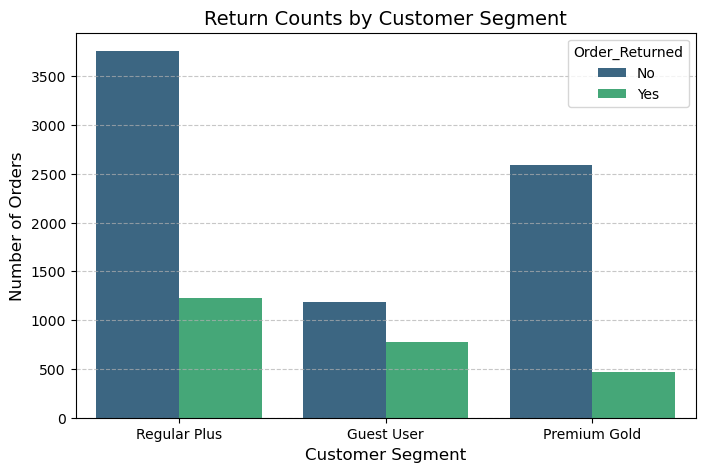

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Customer_Segment', hue='Order_Returned', palette='viridis')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.title('Return Counts by Customer Segment', fontsize=14)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.show()